In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# restauración fuera de foco

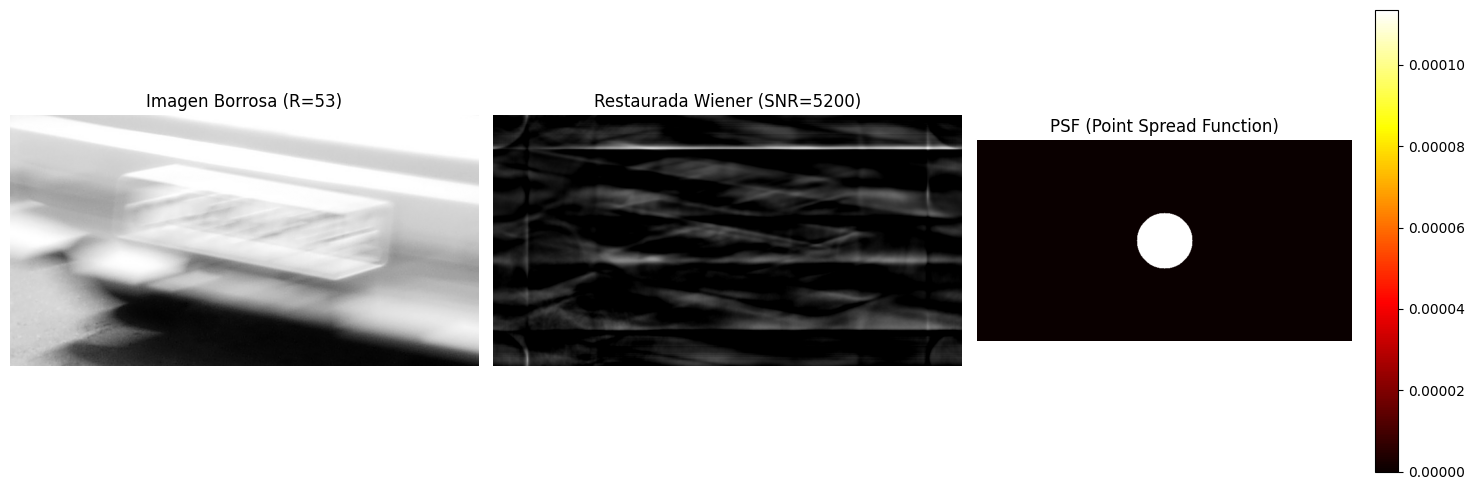

In [2]:

def calc_psf(shape, R):
    """Calcula PSF para desenfoque circular (out-of-focus)"""
    h = np.zeros(shape, dtype=np.float32)
    center = (shape[1]//2, shape[0]//2)
    cv2.circle(h, center, R, 1, -1)
    h = h / np.sum(h)
    return h

def fftshift(img):
    """fftshift para imágenes"""
    return np.fft.fftshift(img)

def ifftshift(img):
    """ifftshift para imágenes"""
    return np.fft.ifftshift(img)

def dft(img):
    """Transformada de Fourier 2D (como en C++)"""
    return np.fft.fft2(img)

def idft(freq):
    """Transformada inversa de Fourier 2D"""
    return np.fft.ifft2(freq)

def filter2dfreq(img, H):
    """Filtrado en frecuencia (como filter2DFreq de C++)"""
    # DFT de la imagen
    G = dft(img)
    
    # Multiplicación en frecuencia (producto elemento por elemento)
    G_filtered = G * H
    
    # IDFT
    result = idft(G_filtered)
    
    return np.real(result)

def calc_wnr_filter(psf, nsr):
    """Calcula filtro Wiener (como calcWnrFilter de C++)"""
    # Aplicar fftshift al PSF
    psf_shifted = fftshift(psf)
    
    # DFT del PSF
    H = dft(psf_shifted)
    
    # |H|^2
    H_abs2 = np.abs(H)**2
    
    # Filtro Wiener: H_conj / (|H|^2 + nsr)
    H_conj = np.conj(H)
    wiener = H_conj / (H_abs2 + nsr)
    
    return wiener

def wiener_filter_out_of_focus(img, R, snr):
    """
    Implementación correcta del filtro Wiener para desenfoque circular
    Basada en el código C++ proporcionado
    """
    # Asegurar dimensiones pares (como en C++)
    rows, cols = img.shape
    rows_even = rows if rows % 2 == 0 else rows - 1
    cols_even = cols if cols % 2 == 0 else cols - 1
    
    if rows != rows_even or cols != cols_even:
        img = img[:rows_even, :cols_even]
    
    # Calcular PSF
    psf = calc_psf(img.shape, R)
    
    # Calcular SNR en el formato correcto
    nsr = 1.0 / snr  # En C++: 1.0/double(snr)
    
    # Calcular filtro Wiener
    Hw = calc_wnr_filter(psf, nsr)
    
    # Aplicar filtro
    img_restored = filter2dfreq(img, Hw)
    
    # Normalizar a [0, 255]
    img_restored = np.clip(img_restored, 0, None)
    img_restored = cv2.normalize(img_restored, None, 0, 255, cv2.NORM_MINMAX)
    img_restored = img_restored.astype(np.uint8)
    
    return img_restored, Hw, psf

def visualizar_wiener(img_blurred, R, snr):
    """Visualización de resultados"""
    img_restored, Hw, psf = wiener_filter_out_of_focus(img_blurred, R, snr)
    
    plt.figure(figsize=(15, 5))
    
    # Original borrosa
    plt.subplot(1, 3, 1)
    plt.title(f'Imagen Borrosa (R={R})')
    plt.imshow(img_blurred, cmap='gray')
    plt.axis('off')
    
    # Restaurada
    plt.subplot(1, 3, 2)
    plt.title(f'Restaurada Wiener (SNR={snr})')
    plt.imshow(img_restored, cmap='gray')
    plt.axis('off')
    
    # PSF
    plt.subplot(1, 3, 3)
    plt.title('PSF (Point Spread Function)')
    plt.imshow(psf, cmap='hot')
    plt.colorbar()
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return img_restored

# Ejemplo de uso:
img = cv2.imread('out_of_focus_image.jpeg', cv2.IMREAD_GRAYSCALE)
img_restored = visualizar_wiener(img, R=53, snr=5200)

catastrofe

# restauración por desenfoque de movimiento

In [5]:
def calc_psf_motion(filter_size: tuple, length: int, theta: float) -> np.ndarray:
    """
    Calcula la PSF para desenfoque de movimiento lineal (Motion Blur)
    tal como lo hacía el código original de C++.
    """
    h = np.zeros(filter_size, dtype=np.float32)
    point = (filter_size[1] // 2, filter_size[0] // 2)

    # Dibujar la línea de desenfoque usando una elipse rellena
    cv2.ellipse(
        h,
        point,
        (0, int(np.round(length / 2.0))),
        90.0 - theta,
        0,
        360,
        255,
        -1  # -1 equivale a FILLED
    )

    summa = np.sum(h)
    return h / summa if summa > 0 else h

def filter_2d_freq(img: np.ndarray, H: np.ndarray) -> np.ndarray:
    """Aplica el filtro en el dominio de la frecuencia mediante la DFT."""
    complex_i = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
    
    # Preparar el filtro complejo Hw
    planes_h = [np.float32(H), np.zeros_like(H, dtype=np.float32)]
    complex_h = cv2.merge(planes_h)
    
    # Multiplicación espectral
    complex_ih = cv2.mulSpectrums(complex_i, complex_h, 0)
    
    # Antitransformada
    img_out = cv2.idft(complex_ih, flags=cv2.DFT_SCALE)
    return cv2.split(img_out)[0]

def calc_wnr_filter(input_h_psf: np.ndarray, nsr: float) -> np.ndarray:
    """Calcula el filtro de restauración de Wiener (G)."""
    h_psf_shifted = np.fft.fftshift(input_h_psf)
    
    planes = [np.float32(h_psf_shifted), np.zeros_like(h_psf_shifted, dtype=np.float32)]
    complex_i = cv2.dft(cv2.merge(planes))
    planes_dft = cv2.split(complex_i)
    
    # Denominador: |H|^2 + NSR
    denom = np.abs(planes_dft[0]) ** 2 + nsr
    return cv2.divide(planes_dft[0], denom)

def edgetaper(img: np.ndarray, gamma: float = 5.0, beta: float = 0.2) -> np.ndarray:
    """Suaviza los bordes para mitigar artefactos cíclicos."""
    ny, nx = img.shape
    x = np.linspace(-np.pi, np.pi, nx, dtype=np.float32)
    w1 = 0.5 * (np.tanh((x + gamma / 2) / beta) - np.tanh((x - gamma / 2) / beta))
    
    y = np.linspace(-np.pi, np.pi, ny, dtype=np.float32)
    w2 = 0.5 * (np.tanh((y + gamma / 2) / beta) - np.tanh((y - gamma / 2) / beta))
    
    w = np.outer(w2, w1)
    return img * w

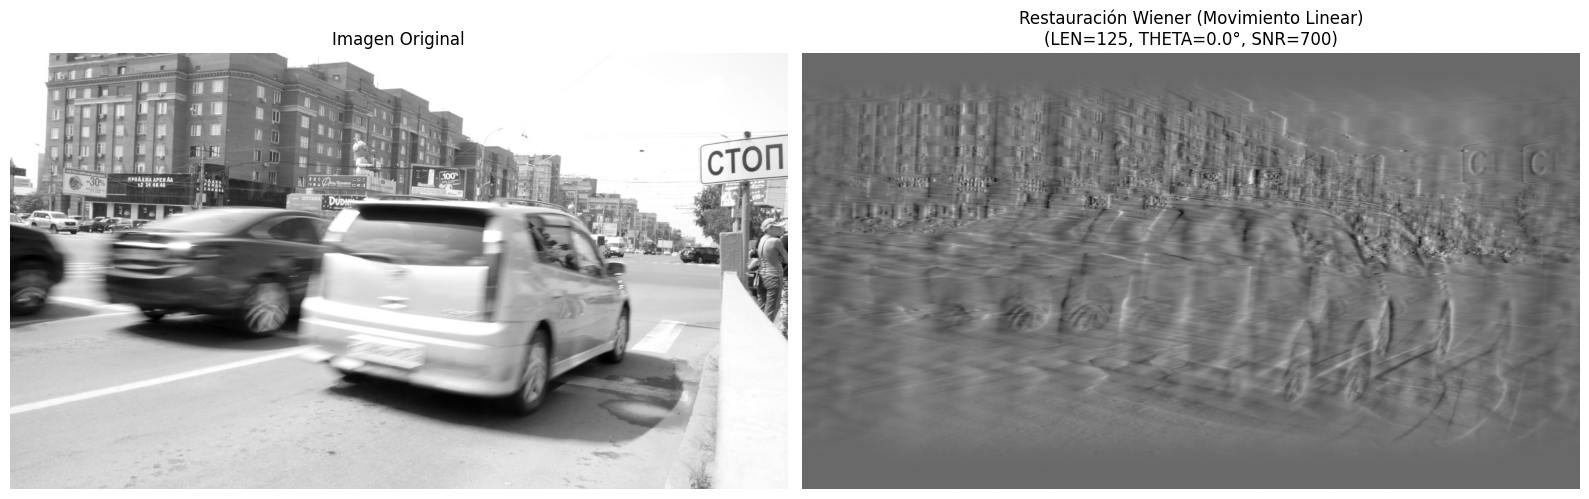

In [8]:
# =====================================================================
# CONFIGURACIÓN CON TUS PARÁMETROS EXACTOS
# =====================================================================
RUTA_IMAGEN = 'movimiento.jfif'
LEN = 125
THETA = 0.0
SNR = 700

# =====================================================================
# PIPELINE DE PROCESAMIENTO
# =====================================================================

# 1. Cargar imagen en escala de grises
img_raw = cv2.imread(RUTA_IMAGEN, cv2.IMREAD_GRAYSCALE)

if img_raw is None:
    print(f"Error: No se pudo cargar la imagen '{RUTA_IMAGEN}'. Asegúrate de que esté en la misma carpeta.")
else:
    # 2. Forzar dimensiones pares (C++: cols & -2)
    h_par, w_par = img_raw.shape[0] & -2, img_raw.shape[1] & -2
    img_in = img_raw[0:h_par, 0:w_par]
    img_in_float = np.float32(img_in)

    # 3. Aplicar Edgetaper para limpiar bordes antes de la FFT
    img_tapered = edgetaper(img_in_float)

    # 4. Calcular la PSF de Movimiento (Línea horizontal por THETA=0)
    h = calc_psf_motion(img_tapered.shape, LEN, THETA)

    # 5. Calcular Filtro de Wiener
    nsr = 1.0 / float(SNR)
    Hw = calc_wnr_filter(h, nsr)

    # 6. Filtrar en frecuencia y normalizar
    img_out = filter_2d_freq(img_tapered, Hw)
    img_out = cv2.normalize(img_out, None, 0, 255, cv2.NORM_MINMAX)
    img_restaurada = np.uint8(img_out)

    # =====================================================================
    # VISUALIZACIÓN DE RESULTADOS
    # =====================================================================
    plt.figure(figsize=(16, 8))

    # Imagen Original
    plt.subplot(1, 2, 1)
    plt.title("Imagen Original")
    plt.imshow(img_in, cmap='gray')
    plt.axis('off')

    # Imagen Restaurada
    plt.subplot(1, 2, 2)
    plt.title(f"Restauración Wiener (Movimiento Linear)\n(LEN={LEN}, THETA={THETA}°, SNR={SNR})")
    plt.imshow(img_restaurada, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

lamentablemente excede mis conocimientos y los del chatgpt se ve. mil disculpas